In [1]:
# data
import numpy as np
# our code
from AdaBoost import AdaBoost, orgenize_data
# visualization
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-v0_8-dark')

In [2]:
# avraging results over 50 runs

train_data, train_labels, test_data, test_labels = orgenize_data(np.loadtxt('squares.txt'))

empirical_error_sums = np.zeros(8)
absolute_error_sums = np.zeros(8)

for run in range(50):

    adaboost = AdaBoost()
    adaboost.train(train_data, train_labels, 15)

    for num_of_rules in range(8):

        tmp = AdaBoost()
        tmp.rules = {rule : adaboost.rules[rule]  for rule in sorted(adaboost.rules, key = lambda k : adaboost.rules[k])[-1 : -num_of_rules -2 : -1]}

        empirical_error_sums[num_of_rules] +=  1 - tmp.test(train_data, train_labels)
        absolute_error_sums[num_of_rules] += 1 - tmp.test(test_data, test_labels)

empirical_error_sums /= 50
absolute_error_sums /= 50

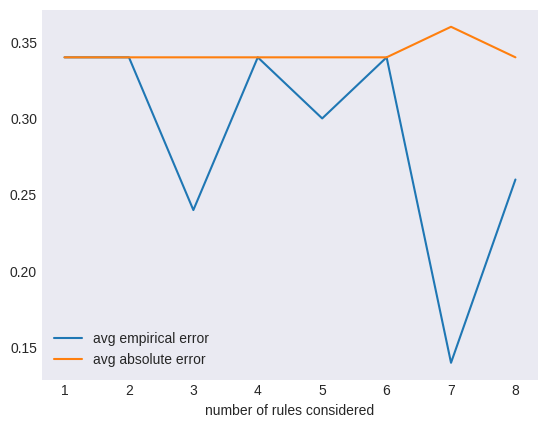

In [3]:
plt.xlabel('number of rules considered')
plt.plot(range(1, 9), empirical_error_sums)
plt.plot(range(1, 9), absolute_error_sums)
plt.legend(['avg empirical error', 'avg absolute error'], loc = 'best')
plt.show()

#### Conclusions

we observe that the consideration of the 2 least important rules left us wrose off.<p>
prior to that however the rules worked together well.

In the middle of the graph ( encouperating 4 - 6 rules) we dont observe much overfitting,<p>
since the empirical error is roughly the absolute error.